In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pathlib
import matplotlib
import matplotlib.colors as colors
from matplotlib import cm, colormaps
from matplotlib.colors import ListedColormap
import gc
import struct
matplotlib.rcParams['xtick.direction'] = 'in'
matplotlib.rcParams['ytick.direction'] = 'in'

In [3]:
class ShallowWaterData:
    def __init__(self, filename):
        with open(filename, 'rb') as f:
            # Read header (t, g)
            self.t, self.g = struct.unpack('dd', f.read(16))

            # Read NX, NY, NGhost
            self.NX, self.NY, self.NGhost = struct.unpack('iii', f.read(12))

            # Compute array sizes
            lenx = self.NX + 2 * self.NGhost
            leny = self.NY + 2 * self.NGhost
            lenArr = lenx * leny

            # Read x, y
            self.x = np.fromfile(f, dtype=np.float64, count=self.NX)
            self.y = np.fromfile(f, dtype=np.float64, count=self.NY)

            # Read main fields
            self.h = np.fromfile(f, dtype=np.float64, count=lenArr).reshape((lenx, leny)).T 
            self.b = np.fromfile(f, dtype=np.float64, count=lenArr).reshape((lenx, leny)).T 
            self.velx = np.fromfile(f, dtype=np.float64, count=lenArr).reshape((lenx, leny)).T 
            self.vely = np.fromfile(f, dtype=np.float64, count=lenArr).reshape((lenx, leny)).T 

    def summary(self):
        print(f"t = {self.t}, g = {self.g}")
        print(f"NX = {self.NX}, NY = {self.NY}, NGhost = {self.NGhost}")
        print(f"h shape = {self.h.shape}, velx shape = {self.velx.shape}, vely shape = {self.vely.shape}")
        print(f"x range = ({self.x[0]:.3f}, {self.x[-1]:.3f})")
        print(f"y range = ({self.y[0]:.3f}, {self.y[-1]:.3f})")

In [4]:
ROOT = pathlib.Path('../')
path = ROOT / f'bin' 

In [5]:
frameid = 0
filename = path / (f'output_'+str(frameid).zfill(5))
frame = ShallowWaterData(filename)
frame.summary()


t = 0.0, g = 1.0
NX = 258, NY = 258, NGhost = 1
h shape = (260, 260), velx shape = (260, 260), vely shape = (260, 260)
x range = (-4.981, 4.981)
y range = (-4.981, 4.981)


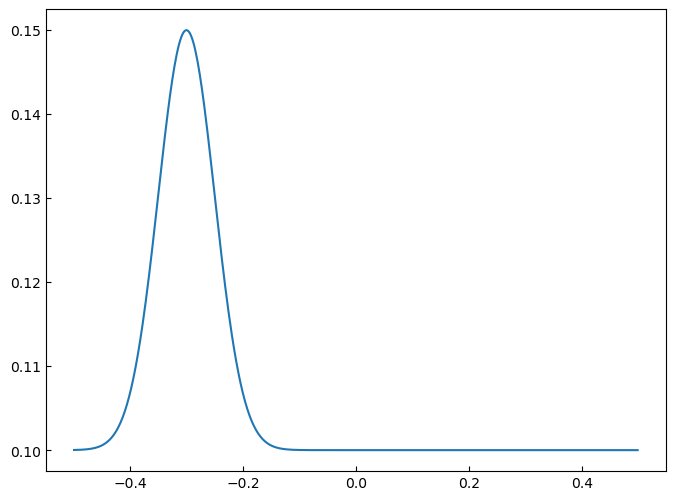

[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.10001813 0.10002117 ... 0.1        0.1        0.        ]
 [0.         0.10001813 0.10002117 ... 0.1        0.1        0.        ]
 ...
 [0.         0.10001813 0.10002117 ... 0.1        0.1        0.        ]
 [0.         0.10001813 0.10002117 ... 0.1        0.1        0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]


In [5]:
plt.figure(figsize=(8,6))
plt.plot(frame.x, frame.h[50,frame.NGhost:frame.NX+frame.NGhost])
plt.show()
print(frame.h)

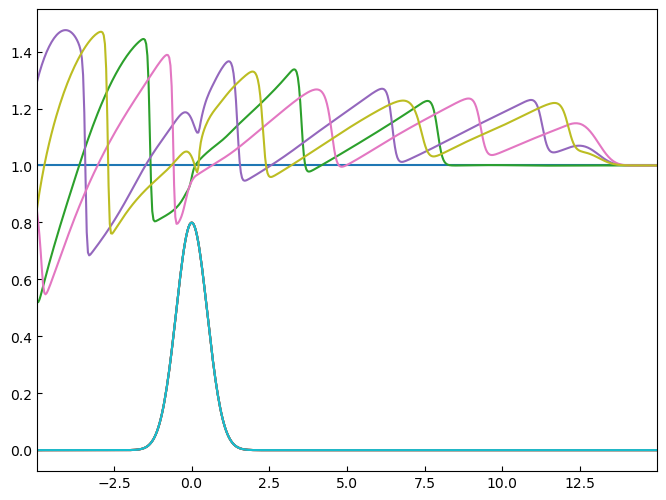

In [8]:
plt.figure(figsize=(8,6))
for frameid in range(0, 501, 103):
# for frameid in range(0, 10, 2):
    filename = path / (f'output_'+str(frameid).zfill(5))
    frame = ShallowWaterData(filename)
    plt.plot(
             frame.x,
             frame.h[128, frame.NGhost:frame.NX+frame.NGhost]
             +frame.b[128, frame.NGhost:frame.NX+frame.NGhost]
             )
    plt.plot(
             frame.x,
             frame.b[128, frame.NGhost:frame.NX+frame.NGhost]
             )
plt.xlim(frame.x[0], frame.x[-1])
# plt.xlim(-8, 5)
# plt.ylim(0.8, 1.2)
# plt.savefig('./wave.png', bbox_inches='tight', dpi=600)
plt.show()

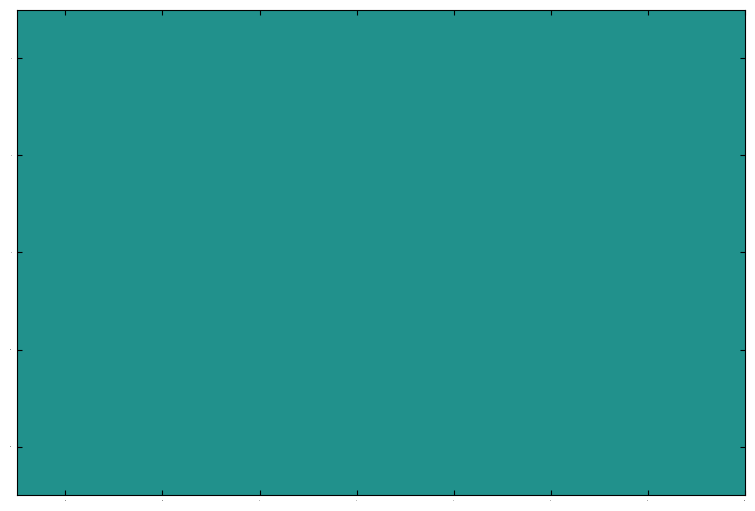

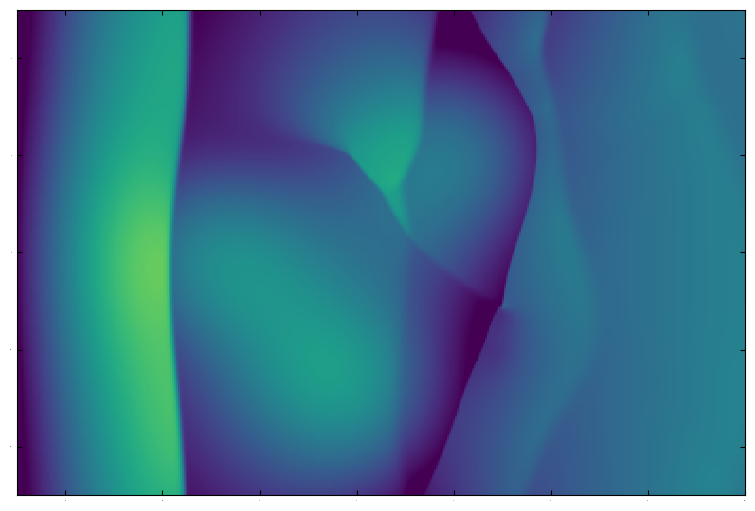

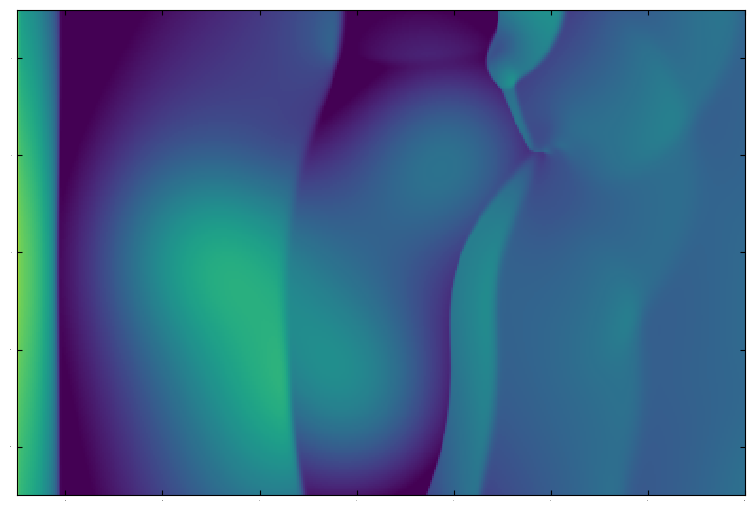

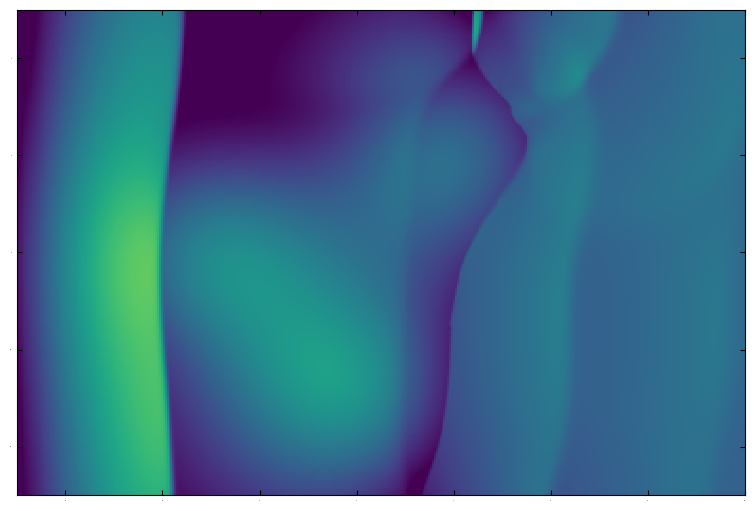

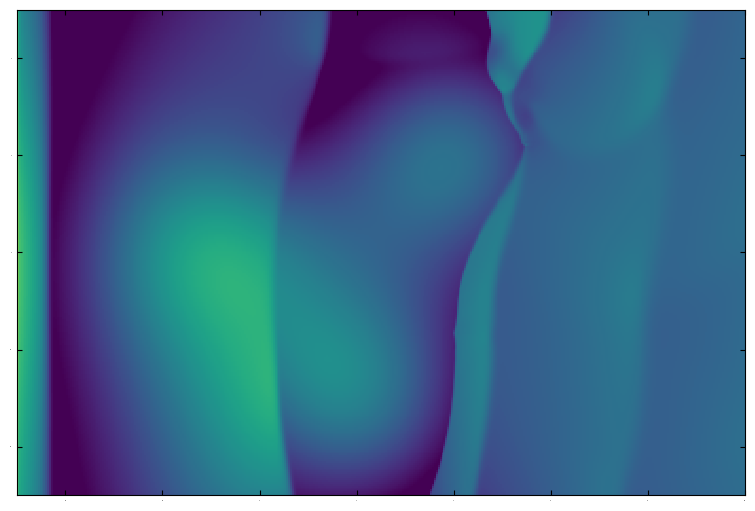

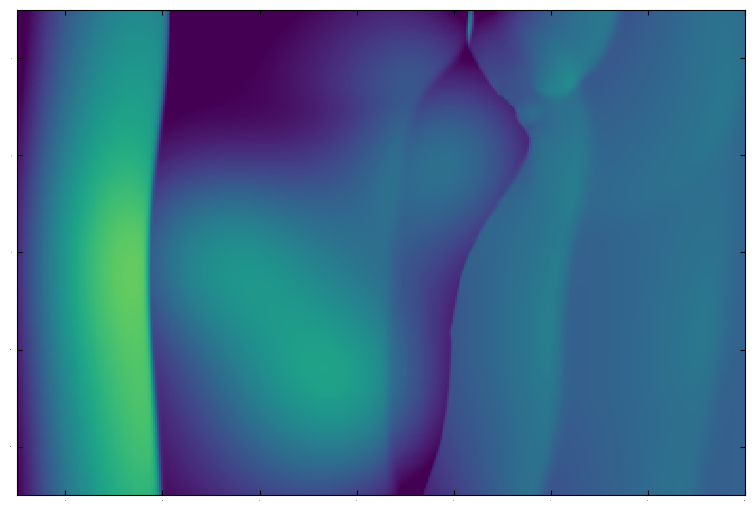

In [20]:
for frameid in range(0, 1001, 179):
    filename = path / (f'output_'+str(frameid).zfill(5))
    frame = ShallowWaterData(filename)
    beg = frame.NGhost
    endx = frame.NX+frame.NGhost
    endy = frame.NY+frame.NGhost

    XX, YY = np.meshgrid(frame.x, frame.y)
    fig, ax = plt.subplots(1, 1, sharey=True, figsize=(8,8))
    plt.subplots_adjust(left = 0.08, right = 0.99, top = 0.96, bottom = 0.08)
    cmap = 'viridis'
    pcm = plt.pcolormesh(XX, YY, frame.h[beg:endy,beg:endx] + frame.b[beg:endy,beg:endx], 
                        #  cmap='viridis',
                         cmap = cmap,
                         norm=colors.Normalize(vmin=0.5, vmax=1.5))
    ax.set_xlim(-5, 10)
    ax.set_ylim(-5, 5)
    ax.set_aspect("equal")
    ax.tick_params(axis='x', labelsize=0, which='both', top=True, bottom=True) 
    ax.tick_params(axis='y', labelsize=0, which='both', left=True, right=True)
    # plt.savefig('./water2D_'+str(frameid).zfill(5)+'.png', bbox_inches='tight', dpi=300)
    # plt.close()
    plt.show()
    print('frame = %5d' % frameid, end='\r')
    # print(np.min(frame.h), np.max(frame.h))
# plt.show()

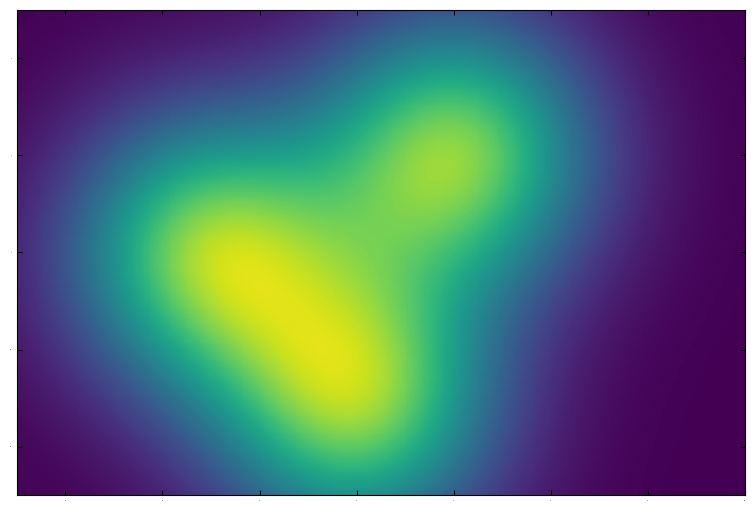

0.9580908439480604


In [26]:
for frameid in range(0, 1, 1):
    filename = path / (f'output_'+str(frameid).zfill(5))
    frame = ShallowWaterData(filename)
    beg = frame.NGhost
    endx = frame.NX+frame.NGhost
    endy = frame.NY+frame.NGhost

    XX, YY = np.meshgrid(frame.x, frame.y)
    fig, ax = plt.subplots(1, 1, sharey=True, figsize=(8,8))
    plt.subplots_adjust(left = 0.08, right = 0.99, top = 0.96, bottom = 0.08)
    cmap = 'viridis'
    pcm = plt.pcolormesh(XX, YY, frame.b[beg:endy,beg:endx], 
                        #  cmap='viridis',
                         cmap = cmap,
                         norm=colors.Normalize(vmin=0., vmax=1.))
    ax.set_xlim(-5, 10)
    ax.set_ylim(-5, 5)
    ax.set_aspect("equal")
    ax.tick_params(axis='x', labelsize=0, which='both', top=True, bottom=True) 
    ax.tick_params(axis='y', labelsize=0, which='both', left=True, right=True)
    # plt.savefig('./water2D_'+str(frameid).zfill(5)+'.png', bbox_inches='tight', dpi=300)
    # plt.close()
    plt.show()
    print('frame = %5d' % frameid, end='\r')
    print(np.max(frame.b[beg:endy,beg:endx]))
    # print(np.min(frame.h), np.max(frame.h))
# plt.show()